In [1]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.6 MB/s eta 0:00:00


[I 2026-03-22 16:10:10,690] A new study created in memory with name: no-name-b5d1f161-75c8-47fc-b72d-c763a7af43b9
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-03-22 16:10:16,264] Trial 0 finished with value: 19.143474578857422 and parameters: {'n_layers': 2, 'n_units': 36, 'learning_rate': 0.0016343146327298143, 'batch_size': 32}. Best is trial 0 with value: 19.143474578857422.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **

Best Params: {'n_layers': 3, 'n_units': 100, 'learning_rate': 0.007713673280232592, 'batch_size': 16}
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1114.4135 - mae: 22.8500 - val_loss: 62.8210 - val_mae: 6.3820
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 39.5433 - mae: 5.0328 - val_loss: 23.4444 - val_mae: 3.9483
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 20.6423 - mae: 3.6426 - val_loss: 14.4644 - val_mae: 3.0505
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11.0371 - mae: 2.6612 - val_loss: 10.7963 - val_mae: 2.6741
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.4391 - mae: 2.4266 - val_loss: 10.2531 - val_mae: 2.4055
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.7177 - mae: 2.4228 - val_loss: 9.5924 - val_mae: 2.3243
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.5997 - mae: 2.3070 - val_loss: 10.8627 - val_mae: 2.6061
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.9561 - mae: 2.4929 - val_loss: 10.2207 - val_mae: 2.5240
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12.0078 - m

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


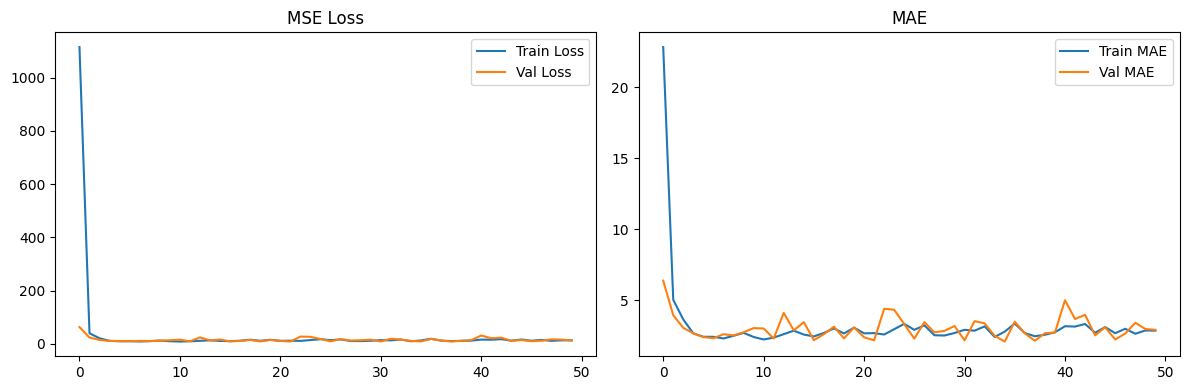

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import optuna
import matplotlib.pyplot as plt

# 1. Generate Synthetic Student Dataset
np.random.seed(42)
n_samples = 2000

data = pd.DataFrame({
    "sleep_hours":           np.random.uniform(4, 10, n_samples),
    "previous_gpa":          np.random.uniform(2.0, 4.0, n_samples),
    "extracurricular":       np.random.randint(0, 2, n_samples),
    "attendance_percentage": np.random.uniform(50, 100, n_samples)
})

data["overall_performance"] = (
    data["sleep_hours"]           * 2.5  +
    data["previous_gpa"]          * 15.0 +
    data["extracurricular"]       * 5.0  +
    data["attendance_percentage"] * 0.4  +
    np.random.normal(0, 3, n_samples)
).clip(0, 100)

# 2. Preprocess
features = ["sleep_hours", "previous_gpa", "extracurricular", "attendance_percentage"]
X = data[features]
y = data[["overall_performance"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Optuna Model Builder
def create_model(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    n_units  = trial.suggest_int("n_units", 32, 128)
    lr       = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    model = tf.keras.Sequential()
    model.add(layers.Dense(n_units, activation="relu", input_shape=(X_train.shape[1],)))
    for _ in range(n_layers):
        model.add(layers.Dense(n_units, activation="relu"))
    model.add(layers.Dense(1))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss="mse", metrics=["mae"])
    return model

def objective(trial):
    model = create_model(trial)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    history = model.fit(X_train, y_train, validation_split=0.2,
                        epochs=20, batch_size=batch_size, verbose=0)
    return min(history.history["val_loss"])

# 4. Run Optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)
print("Best Params:", study.best_params)

# 5. Train Final Model
params = study.best_params
final_model = tf.keras.Sequential()
final_model.add(layers.Dense(params["n_units"], activation="relu", input_shape=(X_train.shape[1],)))
for _ in range(params["n_layers"]):
    final_model.add(layers.Dense(params["n_units"], activation="relu"))
final_model.add(layers.Dense(1))
final_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=params["learning_rate"]),
                    loss="mse", metrics=["mae"])

history = final_model.fit(X_train, y_train, epochs=50,
                          batch_size=params["batch_size"],
                          validation_split=0.2, verbose=1)

# 6. Evaluate
loss, mae = final_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest MSE Loss : {loss:.4f}")
print(f"Test MAE      : {mae:.4f}")

# 7. Predict Sample Student
new_student = np.array([[7.0, 3.2, 1, 85.0]])
new_student_scaled = scaler.transform(new_student)
prediction = final_model.predict(new_student_scaled)
print(f"\nPredicted Overall Performance: {prediction[0][0]:.2f} / 100")

# 8. Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("MSE Loss"); axes[0].legend()
axes[1].plot(history.history["mae"], label="Train MAE")
axes[1].plot(history.history["val_mae"], label="Val MAE")
axes[1].set_title("MAE"); axes[1].legend()
plt.tight_layout()
plt.savefig("training_plot.png")
plt.show()